<div style="border: 5px solid #003366; border-radius: 8px; padding: 20px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 1.2
### **Date:** 03/16/2026
---

This notebook explores the Video Game Sales with Ratings dataset sourced from Kaggle, and found here:

[Video Games with Sales](https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings?resource=download) 
---

We will load, inspect, filter, transform, and clean the data using Pandas, working through ten structured activities covering dimensions, filtering, aggregation, feature engineering, and missing value handling.

</div> 

### **Initial Setup**

In [159]:
# Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress scientific notation and format numbers with commas
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Load the dataset from the current working directory
df = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')

print('✅ Dataset loaded successfully!')
print(f'📦 Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns')
print(f'📋 Columns: {list(df.columns)}')

✅ Dataset loaded successfully!
📦 Shape: 16,719 rows × 16 columns
📋 Columns: ['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']


### Steps 1 & 2 — Load Dataset and Display First Ten Rows

In [160]:
# Display the first ten rows of the dataset
print('🎮 First ten rows of the Video Game Sales dataset:')
df.head(10)

🎮 First ten rows of the Video Game Sales dataset:


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,"2,006.00",Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.00,51.00,8,322.00,Nintendo,E
1,Super Mario Bros.,NES,"1,985.00",Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.00,73.00,8.3,709.00,Nintendo,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.00,73.00,8,192.00,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,"1,989.00",Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,"2,006.00",Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.00,65.00,8.5,431.00,Nintendo,E
7,Wii Play,Wii,"2,006.00",Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.00,41.00,6.6,129.00,Nintendo,E
8,New Super Mario Bros. Wii,Wii,"2,009.00",Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.00,80.00,8.4,594.00,Nintendo,E
9,Duck Hunt,NES,"1,984.00",Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The dataset was successfully loaded as a Pandas DataFrame. The first ten rows give us an early look at the structure and confirm the data loaded as expected.

</div> 

### **Step 3 — Determine Dataset Dimensions**

In [161]:
# Show Dataset Dimensions
rows, cols = df.shape

print(f'🧮 The dataset contains {rows:,} rows and {cols} columns.')
print('\nEach row represents a unique video game entry, and each column represents a specific attribute.')

🧮 The dataset contains 16,719 rows and 16 columns.

Each row represents a unique video game entry, and each column represents a specific attribute.


<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The dataset contains **16,719 rows** and **16 columns**.  
Each row corresponds to a single video game entry, while each column represents an attribute such as platform, genre, sales figures, or critic/user ratings. Understanding the dataset size provides a foundation for the filtering, grouping, and cleaning steps that follow.

</div>

### **Step 4 — Top Five Games by Critic Score**

🏆 Top five games by critic score:
                          Name Platform  Critic_Score
57         Grand Theft Auto IV      PS3         98.00
5350               SoulCalibur       DC         98.00
227   Tony Hawk's Pro Skater 2       PS         98.00
51         Grand Theft Auto IV     X360         98.00
165         Grand Theft Auto V     XOne         97.00


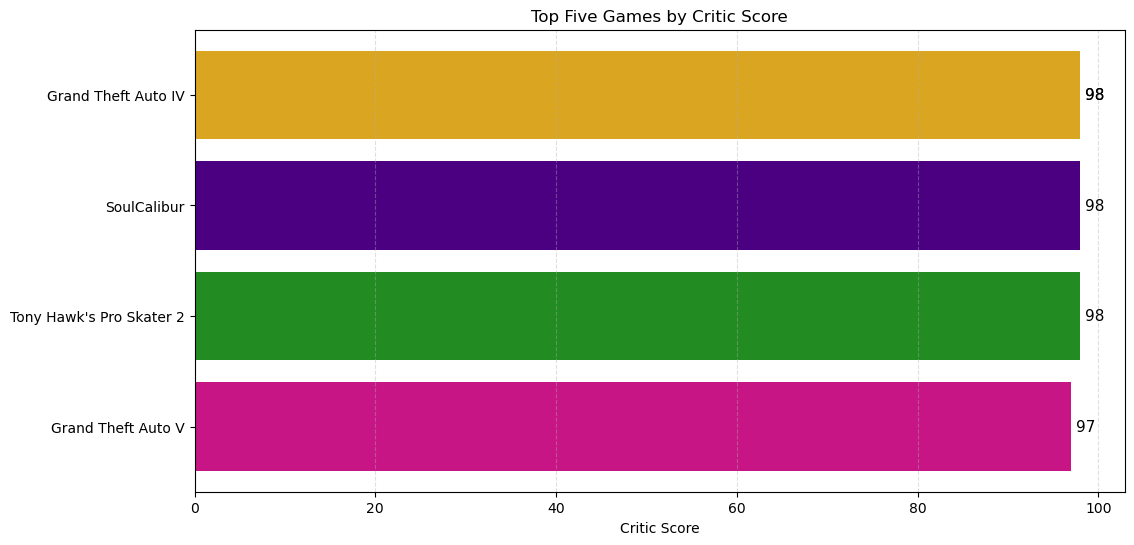

In [162]:
# Show Top Five Games by Critic Score
top_critic = (
    df.sort_values('Critic_Score', ascending=False)
    [['Name', 'Platform', 'Critic_Score']]
    .head(5)
)

print('🏆 Top five games by critic score:')
print(top_critic)

# Visualization - Bar Chart with Values and Individual Colors
colors = ['#4169E1', '#4B0082', '#228B22', '#DAA520', '#C71585']

plt.figure(figsize=(12, 6))
bars = plt.barh(top_critic['Name'], top_critic['Critic_Score'], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}',
        va='center',
        fontsize=11,
        color='black'
    )

plt.xlabel('Critic Score')
plt.title('Top Five Games by Critic Score')
plt.gca().invert_yaxis()  # Highest score at top
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The highest-rated titles in the dataset all achieved **exceptional critic scores**, with four games tied at a near‑perfect score of **98** These include *Grand Theft Auto IV* on both PS3 and Xbox 360, *SoulCalibur* on the Dreamcast, and *Tony Hawk's Pro Skater 2* on the PlayStation. Rounding out the top five is *Grand Theft Auto V* on Xbox One with a score of **97**.

</div>

### **Step 5 — Count Games by Genre**

🎭 Number of video games in each genre:


Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Name: count, dtype: int64

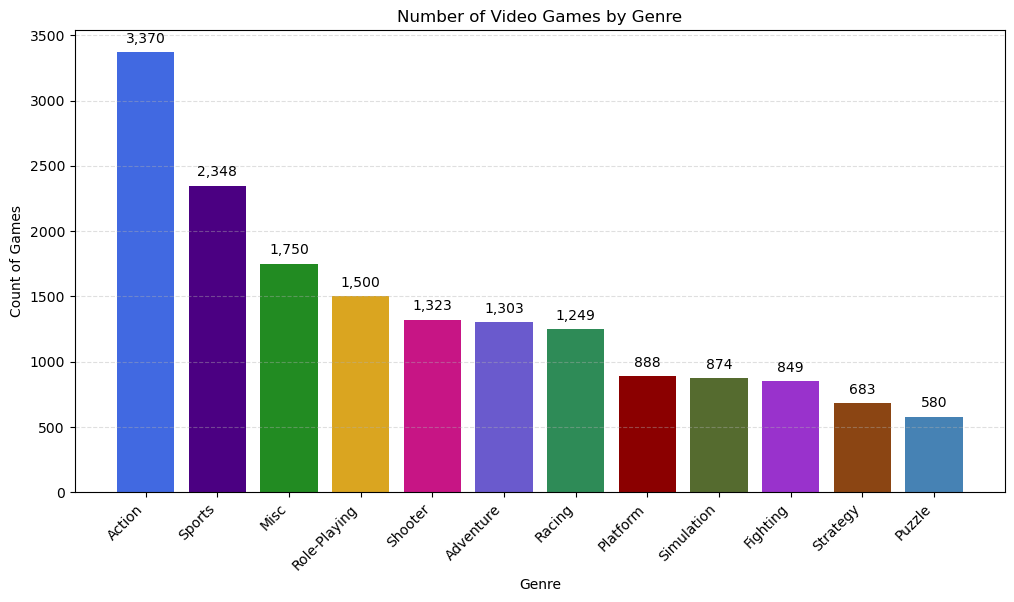

In [163]:
# Count games in each genre
genre_counts = df['Genre'].value_counts().sort_values(ascending=False)

print('🎭 Number of video games in each genre:')
display(genre_counts)

# Visualization — Genre Distribution with Values
plt.figure(figsize=(12, 6))
bars = plt.bar(
    genre_counts.index,
    genre_counts.values,
    color=[
        '#4169E1',
        '#4B0082',
        '#228B22',
        '#DAA520',
        '#C71585',
        '#6A5ACD',
        '#2E8B57',
        '#8B0000',
        '#556B2F',
        '#9932CC',
        '#8B4513',
        '#4682B4'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Number of Video Games by Genre')
plt.xlabel('Genre')
plt.ylabel('Count of Games')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The dataset shows a strong concentration of titles in a few dominant genres. **Action** leads by a wide margin with **3,370 games**, followed by **Sports** (2,348) and **Misc** (1,750). 

Genres such as **Role-Playing**, **Shooter**, and **Adventure** also have substantial representation, each exceeding 1,300 titles.

On the other end of the distribution, genres like **Puzzle**, **Strategy**, and **Fighting** appear less frequently, with counts ranging from roughly 580 to 850 games.

</div>

### **Step 6 — First Five Games on the SNES Platform**

🕹️ First five SNES games in the dataset:


,Name,Platform,Genre,Year_of_Release
18,Super Mario World,SNES,Platform,"1,990.00"
56,Super Mario All-Stars,SNES,Platform,"1,993.00"
71,Donkey Kong Country,SNES,Platform,"1,994.00"
76,Super Mario Kart,SNES,Racing,"1,992.00"
137,Street Fighter II: The World Warrior,SNES,Fighting,"1,992.00"


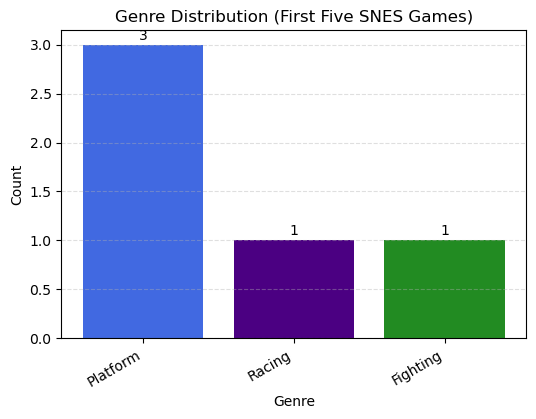

In [164]:
# First 5 Games on SNES
snes_games = df[df['Platform'] == 'SNES'].head(5)

print('🕹️ First five SNES games in the dataset:')
display(snes_games[['Name', 'Platform', 'Genre', 'Year_of_Release']])

# Visualization

plt.figure(figsize=(6, 4))
genre_counts_snes = snes_games['Genre'].value_counts()

bars = plt.bar(
    genre_counts_snes.index,
    genre_counts_snes.values,
    color=[
        '#4169E1',
        '#4B0082',
        '#228B22'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.025,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Genre Distribution (First Five SNES Games)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The first five SNES titles in the dataset highlight several of the console’s most iconic releases.

Three of the five games belong to the *Platform* genre, reflecting the SNES’s strong association with classic side‑scrollers such as **Super Mario World** and **Donkey Kong Country**.  

The remaining two entries represent *Racing* (**Super Mario Kart**) and *Fighting* (**Street Fighter II**).

</div>

### **Step 7 — Top Five Publishers by Total Global Sales**

💰 Top five publishers by total global sales:


Publisher
Nintendo                       $1,788.81M
Electronic Arts                $1,116.96M
Activision                       $731.16M
Sony Computer Entertainment      $606.48M
Ubisoft                          $471.61M
Name: Global_Sales, dtype: str

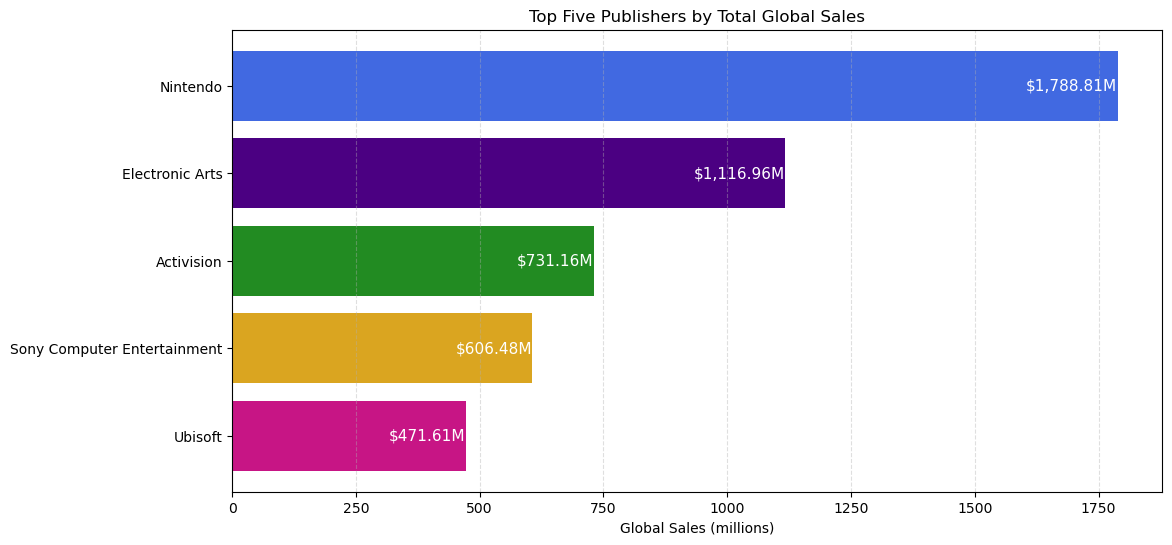

In [165]:
# Aggregate total global sales by publisher
publisher_sales = (
    df.groupby('Publisher')['Global_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

# Adding $ to Sales Values
publisher_sales_formatted = publisher_sales.apply(lambda x: f'${x:,.2f}M')

print('💰 Top five publishers by total global sales:')
display(publisher_sales_formatted)

# Visualization with Values (and $ symbol)
plt.figure(figsize=(12, 6))

colors = ['#4169E1', '#4B0082', '#228B22', '#DAA520', '#C71585']

bars = plt.barh(publisher_sales.index, publisher_sales.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 1,
        bar.get_y() + bar.get_height() / 2,
        f'${width:,.2f}M',
        va='center',
        ha='right',
        fontsize=11,
        color='white' if width > 20 else 'black'
    )

plt.title('Top Five Publishers by Total Global Sales')
plt.xlabel('Global Sales (millions)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The top publishers in the dataset show a clear concentration of global sales among a few major industry leaders.

- **Nintendo** stands far ahead of all competitors with `$1,788.81M` in total global sales, reflecting its long-standing dominance across multiple console generations.
  
- **Electronic Arts** follows with `$1,116.96M`, driven by its strong portfolio of sports and franchise titles.

- **Activision**, **Sony Computer Entertainment**, and **Ubisoft** each contribute between `$471M` and `$731M`, indicating a competitive but noticeably lower tier compared to the top two.

</div>

### **Step 8 — North America Sales Percentage**

📊 First five rows with the new NA Sales Percentage column:


,Name,Platform,NA_Sales,Global_Sales,NA_Percent
0,Wii Sports,Wii,41.36,82.53,50.12
1,Super Mario Bros.,NES,29.08,40.24,72.27
2,Mario Kart Wii,Wii,15.68,35.52,44.14
3,Wii Sports Resort,Wii,15.61,32.77,47.64
4,Pokemon Red/Pokemon Blue,GB,11.27,31.37,35.93


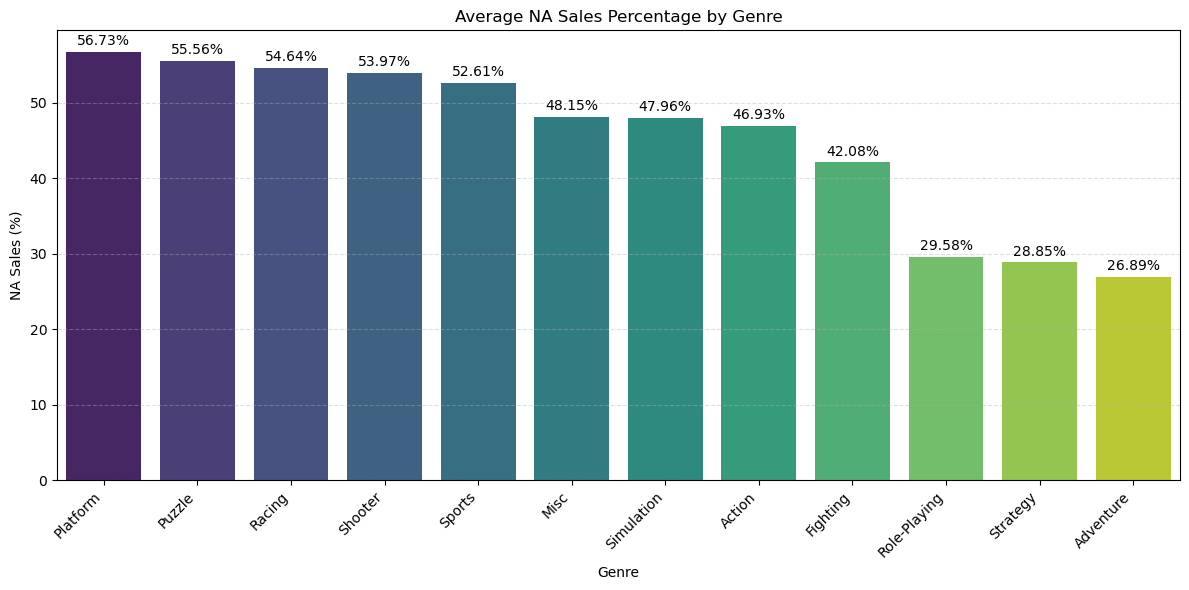

In [166]:
# Create a new column representing NA sales as a percentage of global sales
df['NA_Percent'] = (
    df['NA_Sales'] / df['Global_Sales'].replace(0, np.nan)) * 100

# Display the first five rows of the updated DataFrame
print('📊 First five rows with the new NA Sales Percentage column:')
display(df[['Name', 'Platform', 'NA_Sales', 'Global_Sales', 'NA_Percent']].head(5))

# Group by genre and compute the average NA percentage
genre_na = df.groupby('Genre', as_index=False)['NA_Percent'].mean()

# Sort highest to lowest
genre_na = genre_na.sort_values('NA_Percent', ascending=False)

# Visualization with Values
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=genre_na,
    x='Genre',
    y='NA_Percent',
    hue='Genre',
    legend=False,
    palette='viridis')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title('Average NA Sales Percentage by Genre')
plt.xlabel('Genre')
plt.ylabel('NA Sales (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

A new column `NA_Percent` was added to the DataFrame representing each game's North American sales as a percentage of its total global sales. Division by zero was handled by replacing any zero global sales values with `NaN` before computing the percentage, ensuring no infinite or undefined values were introduced.

Looking at the first five rows, North America accounts for a significant share of global sales across some of the best-selling titles of all time. **Super Mario Bros.** shows the highest NA dependency at **72.27%**, meaning nearly three quarters of its global sales came from North America alone. **Wii Sports** and **Wii Sports Resort** sit around **47–50%**, while **Mario Kart Wii** and **Pokemon Red/Blue** fall closer to **44%** and **36%** respectively, suggesting stronger international reach for those titles.

Overall, the data confirms North America as the dominant regional market for many of the dataset's top-selling games, though the variation across titles highlights that global sales distribution is far from uniform.

</div>

### **Step 9 — Missing Value Audit**

🔍 Missing value audit across all 17 columns:


,Missing Values,Percentage (%)
User_Count,9129,54.60
Critic_Count,8582,51.33
Critic_Score,8582,51.33
Rating,6769,40.49
User_Score,6704,40.10
Developer,6623,39.61
Year_of_Release,269,1.61
Publisher,54,0.32
Name,2,0.01
Genre,2,0.01


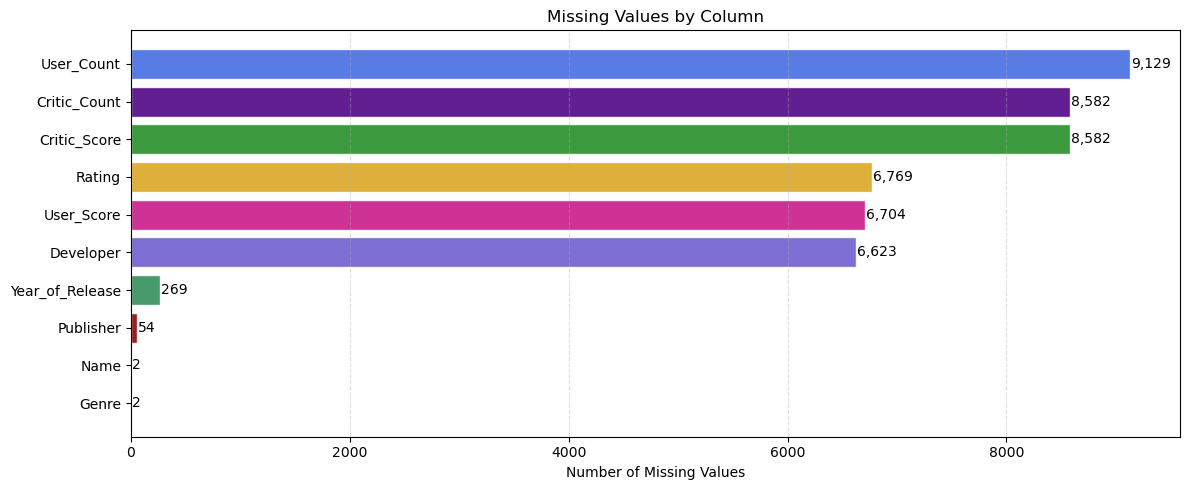

📌 Total columns with missing data: 10 of 17
📌 Total missing values across entire dataset: 46,716


In [167]:
# Count NaN entries across every column in the dataset
nan_counts = df.isnull().sum()
nan_pct = (df.isnull().sum() / len(df)) * 100

# Combine into a clean summary table
nan_summary = pd.DataFrame({
    'Missing Values': nan_counts,
    'Percentage (%)': nan_pct
}).sort_values('Missing Values', ascending=False)

print('🔍 Missing value audit across all 17 columns:')
display(nan_summary)

# Visualize only columns that actually have missing values
nan_plot = nan_summary[nan_summary['Missing Values'] > 0]

colors = [
    '#4169E1', '#4B0082', '#228B22', '#DAA520', '#C71585',
    '#6A5ACD', '#2E8B57', '#8B0000', '#556B2F', '#9932CC'
]

plt.figure(figsize=(12, 5))
bars = plt.barh(
    nan_plot.index,
    nan_plot['Missing Values'],
    color=colors[:len(nan_plot)],
    edgecolor='white',
    alpha=0.88
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 10,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width):,}',
        va='center',
        fontsize=10
    )

plt.title('Missing Values by Column')
plt.xlabel('Number of Missing Values')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(
    f'📌 Total columns with missing data: {(nan_counts > 0).sum()} of {len(nan_counts)}')
print(f'📌 Total missing values across entire dataset: {nan_counts.sum():,}')

<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

The missing value audit revealed that **10 out of 17 columns** contain incomplete data, with a combined total of **46,716 missing values** across the entire dataset after creating the NA Sales % column.

The most severely affected columns are `User_Count`, missing over **54%**, and both `Critic_Count` and `Critic Score` each missing **51.33%**. This means that for roughly half of all games in the dataset, no critic review data exists at all. Rating` and `Developer` are also notably incomplete, missing **40.49%** and **39.61%** of their values, respectively.

On the lower end, `Year_of_Release` is missing only **1.61%** of entries, while `Publisher`, `Name`, and `Genre` each have only a handful of missing values, making them largely complete and reliable for analysis.

The core sales columns, including `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales`, and `Global_Sales` are fully populated with zero missing values, which is reassuring since sales figures are central to most of the analysis performed in this notebook. `User_Score` and `NA_Percent` also show zero missing values, reflecting the cleaning and imputation work completed in earlier steps.

Understanding this distribution of missing data is essential before moving into any modeling pipeline, as columns like `Critic_Score` and `User_Count` would require careful imputation strategies or may need to be excluded depending on the analytical goal.

</div>

### **Step 10 — Replace Missing User Scores with the Median**

In [168]:
# Replace 'tbd' and any other non-numeric placeholders with NaN
df['User_Score'] = df['User_Score'].replace('tbd', np.nan)

# Convert the column to numeric, force non-numeric to NaN
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Count NaNs before imputation
nan_before = df['User_Score'].isna().sum()
print(f'🔍 Missing values before imputation: {nan_before:,}')

# Calculate the median of the cleaned User_Score column
user_median = df['User_Score'].median()
print(f'📌 Median User Score (0–10 scale): {user_median:.2f}')

# Replace all NaN entries with the median
df['User_Score'] = df['User_Score'].fillna(user_median)

# Confirm no missing values remain
nan_after = df['User_Score'].isna().sum()
print(f'✅ Missing values after imputation: {nan_after}')

🔍 Missing values before imputation: 9,129
📌 Median User Score (0–10 scale): 7.50
✅ Missing values after imputation: 0


<div style="border: 3px solid #003366; border-radius: 8px; padding: 20px;">

### Summary

In this step, the `User_Score` column was prepared for modeling by addressing the large number of invalid or missing entries. After converting all non‑numeric values (such as `'tbd'`) to `NaN`, the column contained **9,129 missing values**. With the data cleaned, the median user score on the original 0–10 scale was calculated as **7.50**.

This median value was then used to replace all remaining `NaN` entries in the column. Because the median represents the central value of the valid distribution, filling missing values with the median preserves the overall shape and central tendency of the data without introducing bias. After imputation, the column contained **zero missing values**, ensuring that the dataset is now fully numeric and ready for downstream analysis or machine learning models.

</div>

<div style="border: 5px solid #228B22; border-radius: 8px; padding: 20px;">

### **Overall Reflection:**

This assignment offered a hands-on walkthrough of the full data exploration and preprocessing pipeline using a real-world dataset. Working through each step reinforced how essential it is to validate assumptions before performing any analysis. Engineering the NA_Percent column in Step 8 was a good reminder that feature creation requires defensive coding, such as guarding against division by zero, to avoid silently introducing invalid values. The missing value audit in Step 9 was eye-opening in revealing just how incomplete critic and user review data can be, with over half of all entries missing scores entirely. It is worth noting that Step 9 captures the state of the data before full cleaning is complete... User_Score still contained missing values at that stage, and the summary table reflects that intermediate snapshot rather than a finished result. The process of identifying invalid entries in the User_Score column, converting them to NaN, calculating the median, and performing imputation helped solidify a clear understanding of how missing data can affect downstream tasks. By the end, the dataset was cleaned and consistently structured for the scope of this assignment, though several categorical fields and columns with remaining missing values would still need to be addressed before the data could be considered fully ready for modeling.

---

### **Straightforward Portions:**

- Converting invalid user score values (like 'tbd') into NaN once they were identified.

- Calculating the median after cleaning the column and ensuring it was numeric.

- Performing median imputation to replace missing values in a statistically sound way.

---

### **More Challenging Portions:**

- Understanding why the initial median calculation failed and tracing the issue back to non-numeric entries.

- Ensuring that the cleaning process didn't unintentionally modify valid user scores.

- Reasoning through why the median remains unchanged after imputation and why recalculating it is unnecessary.

</div>